Scratch MSE: 208.4464642184227
Scratch R2: 0.9420490366839492
Sklearn MSE: 208.44646421842273
Sklearn RMSE: 14.437675166674957
Sklearn R2: 0.9420490366839492


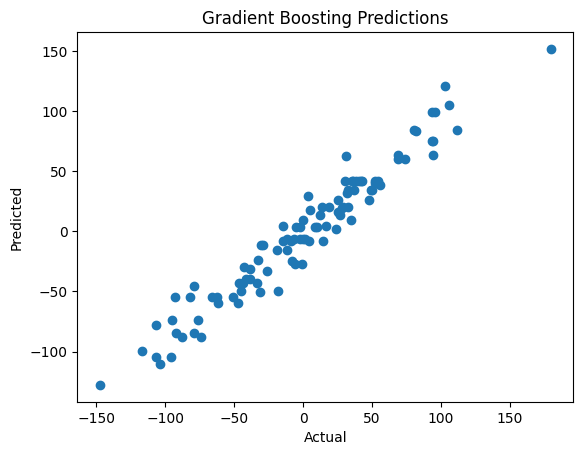

n_estimators: 10 | R2: 0.787227492365628
n_estimators: 50 | R2: 0.9418968572775192
n_estimators: 100 | R2: 0.9420490366839492
n_estimators: 200 | R2: 0.9374932975262334
learning_rate: 0.01 | R2: 0.7742548858757893
learning_rate: 0.05 | R2: 0.9416948055669794
learning_rate: 0.1 | R2: 0.9420490366839492
learning_rate: 0.2 | R2: 0.9396098714074074
max_depth: 1 | R2: 0.939936620297626
max_depth: 2 | R2: 0.9420490366839492
max_depth: 3 | R2: 0.9386727217750215
max_depth: 5 | R2: 0.92611609001313


In [ ]:
# ============================================================
# GRADIENT BOOSTING
# FROM SCRATCH + SCIKIT-LEARN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# 1. CREATE DATASET
# ============================================================

X, y = make_regression(
    n_samples=500,
    n_features=1,
    noise=15,
    random_state=42
)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 3. GRADIENT BOOSTING FROM SCRATCH
# ============================================================

class GradientBoostingScratch:

    def __init__(
        self,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=2
    ):

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

        self.trees = []
        self.initial_prediction = None


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    def fit(self, X, y):

        # Initial prediction = mean of target
        self.initial_prediction = np.mean(y)

        # Current predictions
        predictions = np.full(
            len(y),
            self.initial_prediction
        )

        for _ in range(self.n_estimators):

            # ------------------------------------------------
            # Calculate residuals
            # ------------------------------------------------

            residuals = y - predictions


            # ------------------------------------------------
            # Train a small tree on residuals
            # ------------------------------------------------

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=42
            )

            tree.fit(
                X,
                residuals
            )


            # ------------------------------------------------
            # Predict residuals
            # ------------------------------------------------

            update = tree.predict(X)


            # ------------------------------------------------
            # Update current prediction
            # ------------------------------------------------

            predictions += (
                self.learning_rate * update
            )


            # Save tree
            self.trees.append(tree)

        return self


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        predictions = np.full(
            len(X),
            self.initial_prediction
        )

        for tree in self.trees:

            predictions += (
                self.learning_rate
                * tree.predict(X)
            )

        return predictions


# ============================================================
# 4. TRAIN OUR MODEL
# ============================================================

# Initial prediction
#        ↓
# Calculate residual/error
#        ↓
# Train small tree on error
#        ↓
# Add tree × learning_rate
#        ↓
# New prediction
#        ↓
# New residual
#        ↓
# Repeat
scratch_model = GradientBoostingScratch(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2
)

scratch_model.fit(
    X_train,
    y_train
)


# ============================================================
# 5. PREDICT
# ============================================================

scratch_pred = scratch_model.predict(
    X_test
)


# ============================================================
# 6. EVALUATE
# ============================================================

scratch_mse = mean_squared_error(
    y_test,
    scratch_pred
)

scratch_r2 = r2_score(
    y_test,
    scratch_pred
)

print("Scratch MSE:", scratch_mse)
print("Scratch R2:", scratch_r2)


# ============================================================
# 7. SCIKIT-LEARN IMPLEMENTATION
# ============================================================

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    random_state=42
)


# ============================================================
# 8. TRAIN
# ============================================================

model.fit(
    X_train,
    y_train
)


# ============================================================
# 9. PREDICT
# ============================================================

pred = model.predict(
    X_test
)


# ============================================================
# 10. EVALUATE
# ============================================================

mse = mean_squared_error(
    y_test,
    pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    pred
)

print("Sklearn MSE:", mse)
print("Sklearn RMSE:", rmse)
print("Sklearn R2:", r2)


# ============================================================
# 11. PLOT PREDICTIONS
# ============================================================

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting Predictions")

plt.show()


# ============================================================
# 12. EXPERIMENT WITH NUMBER OF TREES
# ============================================================

for n in [10, 50, 100, 200]:

    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=2,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    score = model.score(
        X_test,
        y_test
    )

    print(
        "n_estimators:",
        n,
        "| R2:",
        score
    )


# ============================================================
# 13. EXPERIMENT WITH LEARNING RATE
# ============================================================

for lr in [0.01, 0.05, 0.1, 0.2]:

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=2,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    score = model.score(
        X_test,
        y_test
    )

    print(
        "learning_rate:",
        lr,
        "| R2:",
        score
    )


# ============================================================
# 14. EXPERIMENT WITH TREE DEPTH
# ============================================================

for depth in [1, 2, 3, 5]:

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    score = model.score(
        X_test,
        y_test
    )

    print(
        "max_depth:",
        depth,
        "| R2:",
        score
    )


# ============================================================
# 15. IMPORTANT PARAMETERS
# ============================================================

# n_estimators
#
# Number of trees.
#
# More trees:
#   Can improve performance
#   Increases training time
#
#
# learning_rate
#
# Controls how much each tree contributes.
#
# Small learning_rate:
#   Slower learning
#   Usually requires more trees
#
# Large learning_rate:
#   Faster learning
#   Can overfit
#
#
# max_depth
#
# Depth of each weak tree.
#
# Smaller:
#   Simpler trees
#
# Larger:
#   More powerful trees
#   Higher overfitting risk
#
#
# min_samples_split
#
# Minimum samples required to split a node.
#
#
# min_samples_leaf
#
# Minimum samples required in a leaf.
#
#
# subsample
#
# Fraction of training samples used for each tree.
#
# < 1.0 → stochastic gradient boosting
#
#
# max_features
#
# Number of features considered when finding splits.
#
#
# random_state
#
# Makes results reproducible.


# ============================================================
# 16. CORE WORKING — NOTES
# ============================================================

# Gradient Boosting:
#
# Step 1:
# Start with a simple prediction.
#
# For squared-error regression:
#
#     initial_prediction = mean(y)
#
#
# Step 2:
# Calculate residuals:
#
#     residual = y - prediction
#
#
# Step 3:
# Train a small Decision Tree
# to predict the residuals.
#
#
# Step 4:
# Update predictions:
#
#     prediction =
#         prediction
#         + learning_rate * tree_prediction
#
#
# Step 5:
# Calculate new residuals.
#
#
# Step 6:
# Train another tree on the new residuals.
#
#
# Repeat many times.
#
#
# Final model:
#
# F(x) =
# initial_prediction
# + learning_rate * tree1(x)
# + learning_rate * tree2(x)
# + ...
# + learning_rate * treeN(x)


# ============================================================
# 17. IMPORTANT FORMULA
# ============================================================

# General Gradient Boosting:
#
#     F_m(x) =
#     F_(m-1)(x)
#     + learning_rate * h_m(x)
#
#
# where:
#
# F_(m-1) = current model
#
# h_m = new tree
#
# learning_rate = contribution of new tree
#
#
# For squared-error regression:
#
# Negative gradient = residual
#
#     residual = y - F(x)


# ============================================================
# 18. INTERVIEW SUMMARY
# ============================================================

# Gradient Boosting builds weak Decision Trees
# sequentially.
#
# Each new tree tries to correct the errors
# made by the current ensemble.
#
# Random Forest:
#
#   Trees are independent
#   → Bagging
#   → Reduce variance
#
# Gradient Boosting:
#
#   Trees are sequential
#   → Boosting
#   → Correct previous errors
#
#
# Important parameters:
#
#   n_estimators
#   learning_rate
#   max_depth
#   min_samples_split
#   min_samples_leaf
#   subsample